# 02 — Exploratory Data Analysis & Risk Segmentation

## Objective

Understand the borrower population and the simulated Control vs Treatment experiment **before formal hypothesis testing**.

This notebook focuses on distributions, data quality, treatment/control comparability, risk segmentation, and the relationship between borrower characteristics and simulated default.

> **Important:** This notebook is descriptive. Formal statistical tests are reserved for `03_hypothesis_testing.ipynb`.


## 1. Imports and project paths


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_policy_experiment.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed experiment dataset not found: {DATA_PATH}. Run Notebook 01 first."
    )

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Load the experiment dataset


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

display(df.head())


Rows: 1,302,848
Columns: 17


,loan_id,loan_status,observed_default,annual_income,loan_amount,dti_ratio,employment_years,interest_rate,term,grade,issue_date,policy_group,baseline_pd,policy_pd,simulated_default,approval_prob,approved
0,NaN,Fully Paid,0,"100,000.0000",30000,30.4600,5.0000,22.3500,36 months,D,2018-12-01,treatment,0.2964,0.2844,0,0.9000,0
1,NaN,Fully Paid,0,"45,000.0000",40000,50.5300,0.0000,16.1400,60 months,C,2018-12-01,control,0.6441,0.6441,1,1.0000,1
2,NaN,Fully Paid,0,"100,000.0000",20000,18.9200,10.0000,7.5600,36 months,A,2018-12-01,treatment,0.1802,0.1682,0,0.9950,1
3,NaN,Fully Paid,0,"38,500.0000",4500,4.6400,10.0000,11.3100,36 months,B,2018-12-01,treatment,0.1120,0.1000,0,0.9950,1
4,NaN,Fully Paid,0,"450,000.0000",8425,12.3700,3.0000,27.2700,36 months,E,2018-12-01,control,0.0518,0.0518,0,1.0000,1


## 3. Dataset quality overview


In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(quality)


,dtype,missing_count,missing_pct,unique_values
loan_id,float64,1302848,100.0000,0
employment_years,float64,74928,5.7511,11
loan_status,object,0,0.0000,3
annual_income,float64,0,0.0000,62917
observed_default,int64,0,0.0000,2
loan_amount,int64,0,0.0000,1553
dti_ratio,float64,0,0.0000,6432
interest_rate,float64,0,0.0000,654
term,object,0,0.0000,2
grade,object,0,0.0000,7


## 4. Experiment population and policy groups


In [4]:
group_summary = (
    df.groupby("policy_group")
    .agg(
        borrowers=("policy_group", "size"),
        approval_rate=("approved", "mean"),
        default_rate=("simulated_default", "mean"),
        average_pd=("policy_pd", "mean"),
        average_loan=("loan_amount", "mean"),
        average_income=("annual_income", "mean"),
        average_dti=("dti_ratio", "mean")
    )
    .reset_index()
)

display(group_summary)


,policy_group,borrowers,approval_rate,default_rate,average_pd,average_loan,average_income,average_dti
0,control,651872,1.0000,0.2010,0.2007,"14,406.1492","76,129.2696",18.1683
1,treatment,650976,0.9758,0.1891,0.1887,"14,422.2892","76,272.8011",18.1694


## 5. Core experiment KPIs


In [5]:
control = df[df["policy_group"] == "control"]
treatment = df[df["policy_group"] == "treatment"]

control_default = control["simulated_default"].mean()
treatment_default = treatment["simulated_default"].mean()
control_approval = control["approved"].mean()
treatment_approval = treatment["approved"].mean()

kpis = pd.Series({
    "Control default rate": control_default,
    "Treatment default rate": treatment_default,
    "Default reduction (pp)": control_default - treatment_default,
    "Control approval rate": control_approval,
    "Treatment approval rate": treatment_approval,
    "Approval reduction (pp)": control_approval - treatment_approval,
    "Control average PD": control["policy_pd"].mean(),
    "Treatment average PD": treatment["policy_pd"].mean(),
})

display(kpis.to_frame("value"))


,value
Control default rate,0.2010
Treatment default rate,0.1891
Default reduction (pp),0.0119
Control approval rate,1.0000
Treatment approval rate,0.9758
Approval reduction (pp),0.0242
Control average PD,0.2007
Treatment average PD,0.1887


## 6. Default-rate comparison


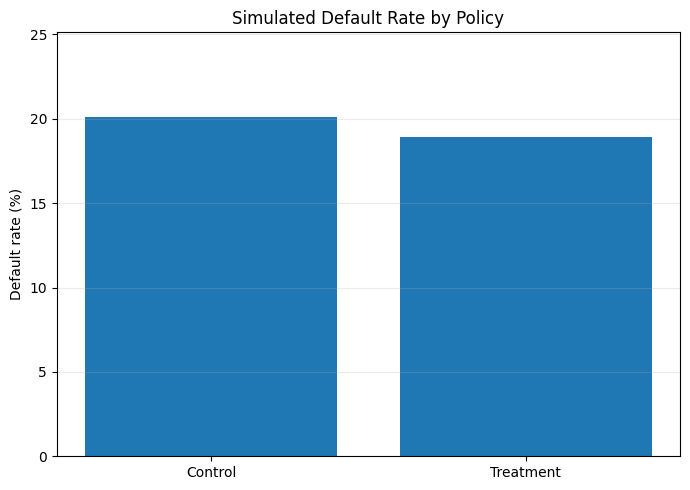

In [6]:
rates = pd.DataFrame({
    "Policy": ["Control", "Treatment"],
    "Default Rate": [control_default, treatment_default]
})

plt.figure(figsize=(7, 5))
plt.bar(rates["Policy"], rates["Default Rate"] * 100)
plt.ylabel("Default rate (%)")
plt.title("Simulated Default Rate by Policy")
plt.ylim(0, max(rates["Default Rate"] * 100) * 1.25)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Approval-rate comparison


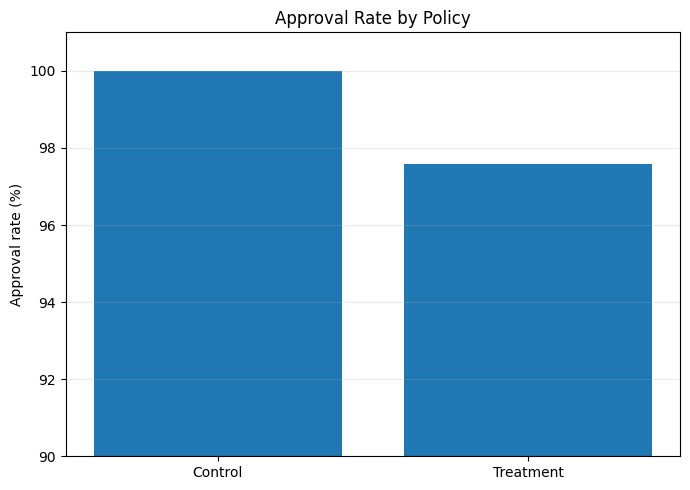

In [7]:
approval_rates = pd.DataFrame({
    "Policy": ["Control", "Treatment"],
    "Approval Rate": [control_approval, treatment_approval]
})

plt.figure(figsize=(7, 5))
plt.bar(approval_rates["Policy"], approval_rates["Approval Rate"] * 100)
plt.ylabel("Approval rate (%)")
plt.title("Approval Rate by Policy")
plt.ylim(90, 101)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Borrower distributions


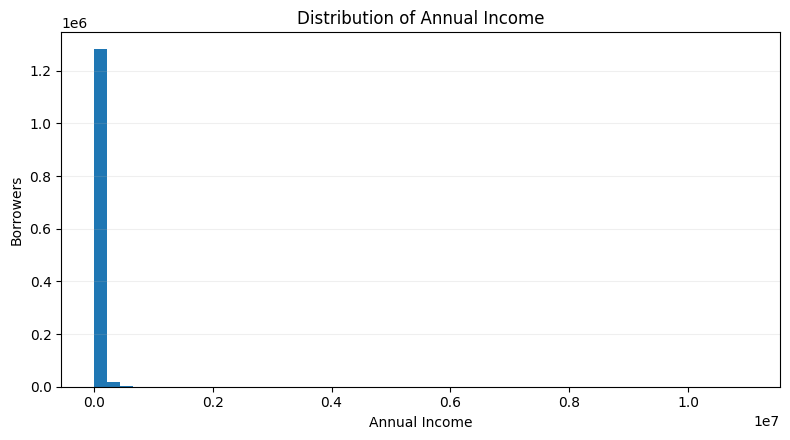

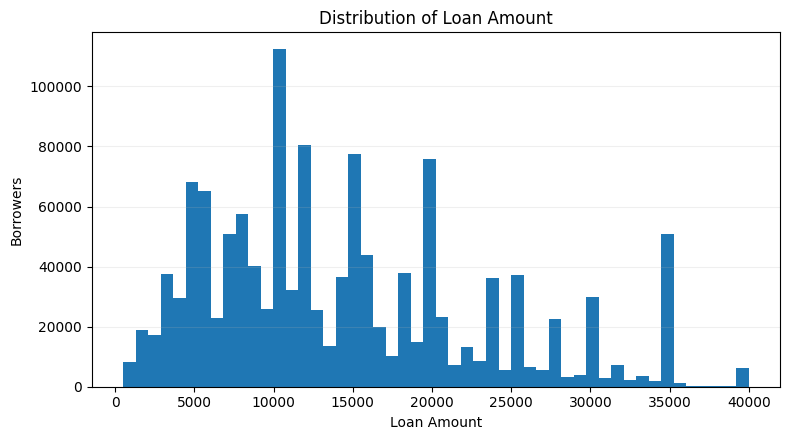

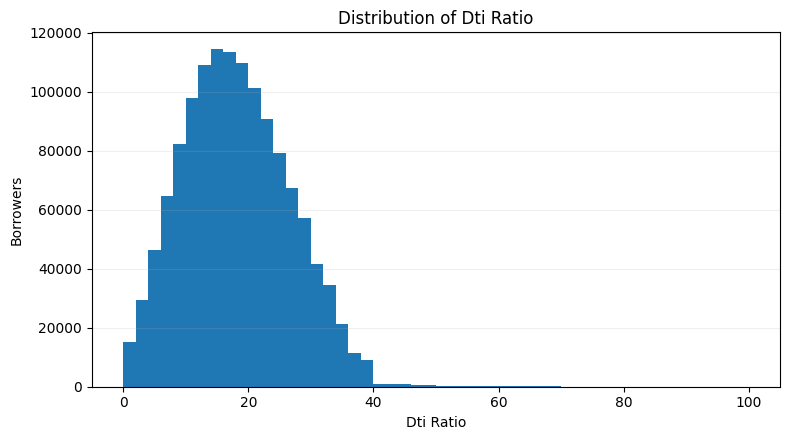

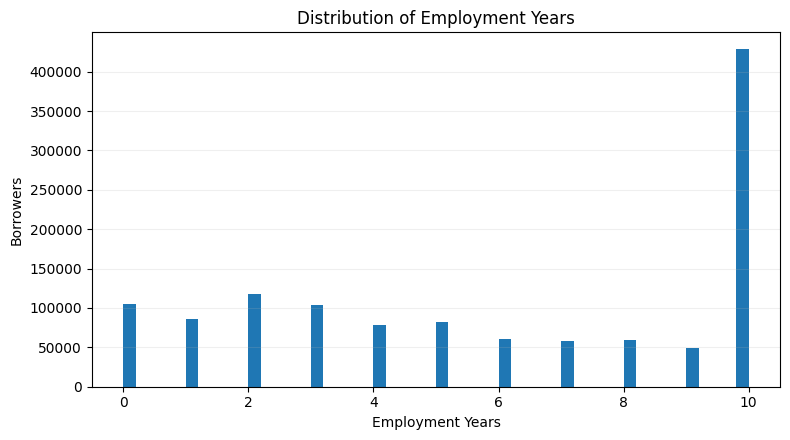

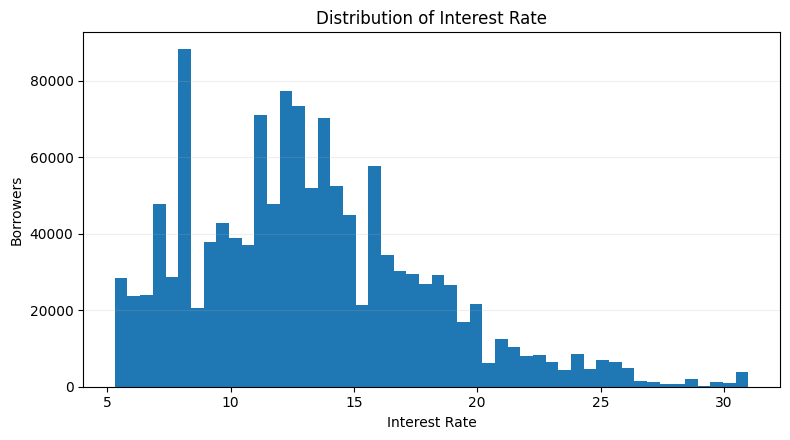

In [8]:
numeric_features = [
    col for col in [
        "annual_income", "loan_amount", "dti_ratio",
        "employment_years", "interest_rate"
    ] if col in df.columns
]

for col in numeric_features:
    plt.figure(figsize=(8, 4.5))
    plt.hist(df[col].dropna(), bins=50)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Borrowers")
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.grid(axis="y", alpha=0.20)
    plt.tight_layout()
    plt.show()


## 9. Treatment/control balance


In [9]:
balance_features = [
    col for col in [
        "annual_income", "loan_amount", "dti_ratio",
        "employment_years", "interest_rate"
    ] if col in df.columns
]

rows = []
for col in balance_features:
    c = control[col].dropna()
    t = treatment[col].dropna()
    pooled_sd = np.sqrt((c.var(ddof=1) + t.var(ddof=1)) / 2)
    smd = (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    rows.append({
        "feature": col,
        "control_mean": c.mean(),
        "treatment_mean": t.mean(),
        "absolute_difference": t.mean() - c.mean(),
        "standardized_mean_difference": smd
    })

balance = pd.DataFrame(rows)
display(balance)


,feature,control_mean,treatment_mean,absolute_difference,standardized_mean_difference
0,annual_income,"76,129.2696","76,272.8011",143.5315,0.0020
1,loan_amount,"14,406.1492","14,422.2892",16.1400,0.0019
2,dti_ratio,18.1683,18.1694,0.0011,0.0001
3,employment_years,5.9680,5.9710,0.0030,0.0008
4,interest_rate,13.2577,13.2541,-0.0036,-0.0008


### Balance interpretation

An absolute standardized mean difference below roughly 0.10 is generally considered small. This is a descriptive diagnostic, not a substitute for the formal tests in Notebook 03.


## 10. Risk segmentation


In [10]:
df["dti_band"] = pd.cut(
    df["dti_ratio"],
    bins=[-np.inf, 10, 20, 30, 40, np.inf],
    labels=["<10", "10–20", "20–30", "30–40", "40+"]
)

df["income_band"] = pd.qcut(
    df["annual_income"],
    q=5,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"],
    duplicates="drop"
)

df["loan_band"] = pd.qcut(
    df["loan_amount"],
    q=5,
    labels=["Q1 Smallest", "Q2", "Q3", "Q4", "Q5 Largest"],
    duplicates="drop"
)

display(df[["dti_band", "income_band", "loan_band"]].head())


,dti_band,income_band,loan_band
0,30–40,Q4,Q5 Largest
1,40+,Q2,Q5 Largest
2,10–20,Q4,Q4
3,<10,Q1 Lowest,Q1 Smallest
4,10–20,Q5 Highest,Q2


## 11. Default rate by DTI band


In [11]:
dti_summary = (
    df.groupby(["dti_band", "policy_group"], observed=True)
    .agg(
        borrowers=("simulated_default", "size"),
        default_rate=("simulated_default", "mean"),
        approval_rate=("approved", "mean")
    )
    .reset_index()
)
display(dti_summary)


,dti_band,policy_group,borrowers,default_rate,approval_rate
0,<10,control,119774,0.1125,1.0000
1,<10,treatment,118866,0.1002,0.9948
2,10–20,control,272355,0.1680,1.0000
3,10–20,treatment,272847,0.1560,0.9940
4,20–30,control,197989,0.2501,1.0000
5,20–30,treatment,198006,0.2394,0.9603
6,30–40,control,58924,0.3505,1.0000
7,30–40,treatment,58465,0.3345,0.9079
8,40+,control,2830,0.5830,1.0000
9,40+,treatment,2792,0.5949,0.9065


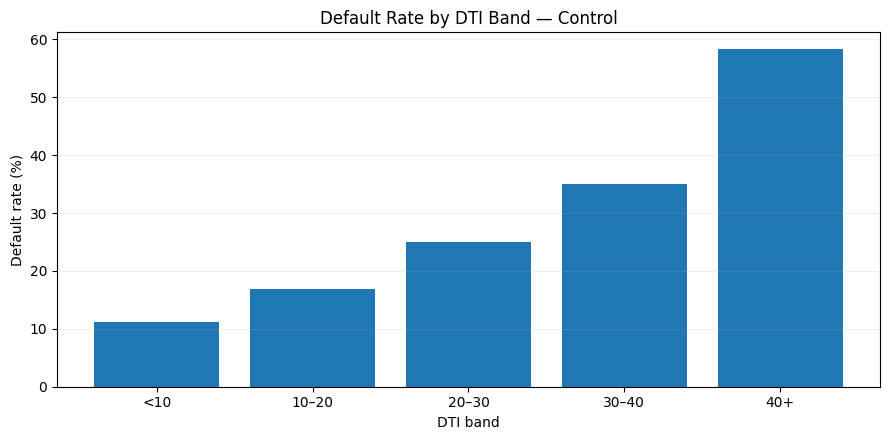

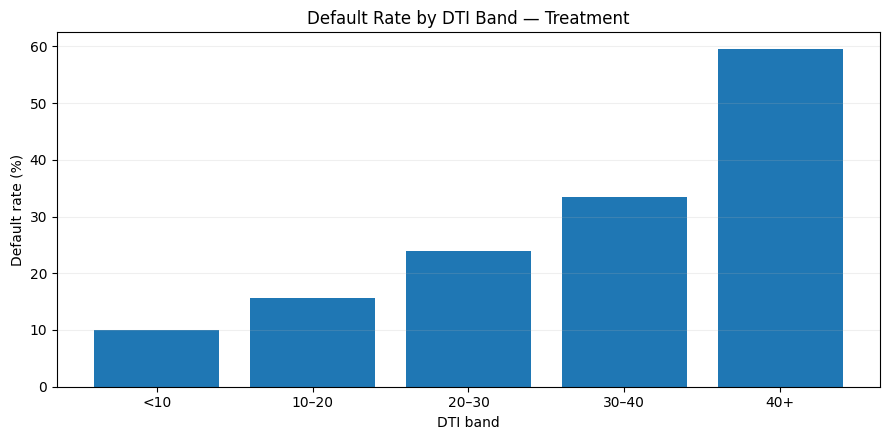

In [12]:
for group in ["control", "treatment"]:
    subset = dti_summary[dti_summary["policy_group"] == group]
    plt.figure(figsize=(9, 4.5))
    plt.bar(subset["dti_band"].astype(str), subset["default_rate"] * 100)
    plt.xlabel("DTI band")
    plt.ylabel("Default rate (%)")
    plt.title(f"Default Rate by DTI Band — {group.title()}")
    plt.grid(axis="y", alpha=0.20)
    plt.tight_layout()
    plt.show()


## 12. Policy effect by DTI segment


In [13]:
segment_effect = (
    df.groupby(["dti_band", "policy_group"], observed=True)["simulated_default"]
    .mean()
    .unstack()
    .reset_index()
)

if {"control", "treatment"}.issubset(segment_effect.columns):
    segment_effect["default_reduction_pp"] = (
        segment_effect["control"] - segment_effect["treatment"]
    ) * 100

display(segment_effect)


policy_group,dti_band,control,treatment,default_reduction_pp
0,<10,0.1125,0.1002,1.2298
1,10–20,0.1680,0.1560,1.1917
2,20–30,0.2501,0.2394,1.0723
3,30–40,0.3505,0.3345,1.5995
4,40+,0.5830,0.5949,-1.1875


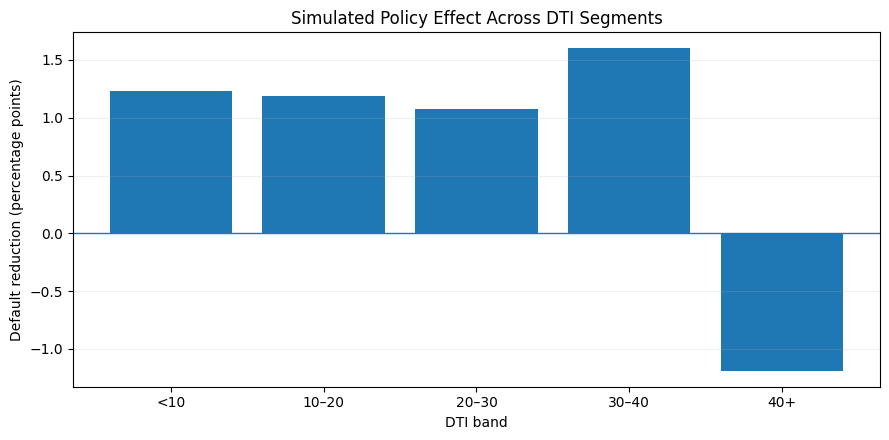

In [14]:
if "default_reduction_pp" in segment_effect.columns:
    plt.figure(figsize=(9, 4.5))
    plt.bar(segment_effect["dti_band"].astype(str), segment_effect["default_reduction_pp"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("DTI band")
    plt.ylabel("Default reduction (percentage points)")
    plt.title("Simulated Policy Effect Across DTI Segments")
    plt.grid(axis="y", alpha=0.20)
    plt.tight_layout()
    plt.show()


## 13. Default rate by income segment


In [15]:
income_summary = (
    df.groupby(["income_band", "policy_group"], observed=True)
    .agg(
        borrowers=("simulated_default", "size"),
        default_rate=("simulated_default", "mean"),
        approval_rate=("approved", "mean")
    )
    .reset_index()
)
display(income_summary)


,income_band,policy_group,borrowers,default_rate,approval_rate
0,Q1 Lowest,control,132832,0.2613,1.0000
1,Q1 Lowest,treatment,132664,0.2480,0.9543
2,Q2,control,130944,0.2241,1.0000
3,Q2,treatment,129599,0.2130,0.9695
4,Q3,control,128704,0.2031,1.0000
5,Q3,treatment,128682,0.1899,0.9782
6,Q4,control,138724,0.1768,1.0000
7,Q4,treatment,139199,0.1660,0.9855
8,Q5 Highest,control,120668,0.1352,1.0000
9,Q5 Highest,treatment,120832,0.1244,0.9924


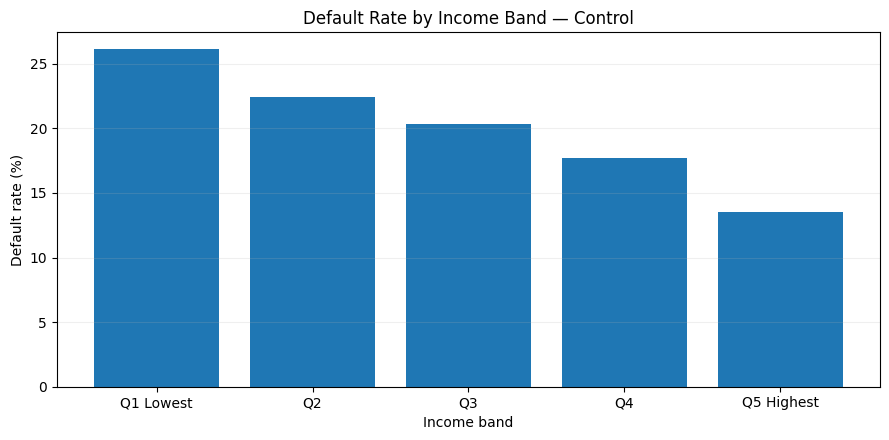

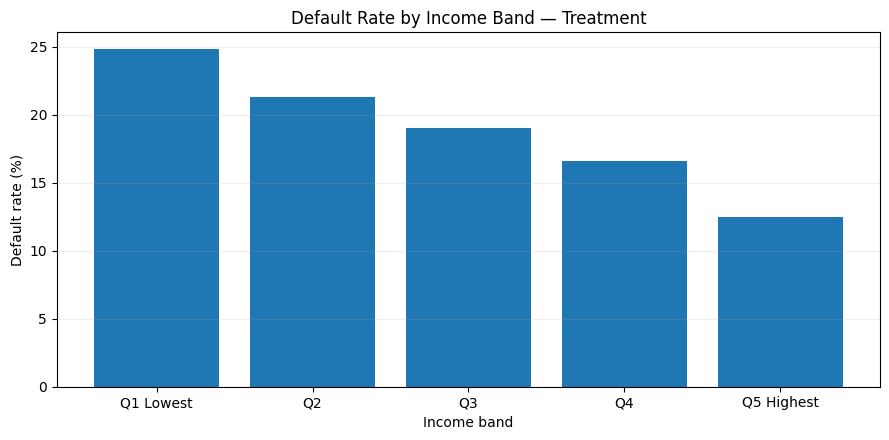

In [16]:
for group in ["control", "treatment"]:
    subset = income_summary[income_summary["policy_group"] == group]
    plt.figure(figsize=(9, 4.5))
    plt.bar(subset["income_band"].astype(str), subset["default_rate"] * 100)
    plt.xlabel("Income band")
    plt.ylabel("Default rate (%)")
    plt.title(f"Default Rate by Income Band — {group.title()}")
    plt.grid(axis="y", alpha=0.20)
    plt.tight_layout()
    plt.show()


## 14. Loan amount and default risk


In [17]:
loan_summary = (
    df.groupby(["loan_band", "policy_group"], observed=True)
    .agg(
        borrowers=("simulated_default", "size"),
        default_rate=("simulated_default", "mean"),
        approval_rate=("approved", "mean"),
        average_dti=("dti_ratio", "mean")
    )
    .reset_index()
)
display(loan_summary)


,loan_band,policy_group,borrowers,default_rate,approval_rate,average_dti
0,Q1 Smallest,control,131179,0.1764,1.0000,17.4080
1,Q1 Smallest,treatment,130423,0.1664,0.9815,17.4540
2,Q2,control,137650,0.1993,1.0000,17.8001
3,Q2,treatment,138042,0.1866,0.9766,17.7912
4,Q3,control,137953,0.2106,1.0000,18.4176
5,Q3,treatment,137605,0.2006,0.9729,18.4527
6,Q4,control,116518,0.2138,1.0000,18.8022
7,Q4,treatment,116160,0.2008,0.9717,18.7901
8,Q5 Largest,control,128572,0.2060,1.0000,18.4961
9,Q5 Largest,treatment,128746,0.1920,0.9759,18.4369


## 15. Historical vs simulated experimental default

The historical outcome is kept separate from the simulated experiment outcome. This prevents us from accidentally presenting the policy effect as an observed Lending Club result.


In [18]:
comparison = pd.DataFrame({
    "Metric": [
        "Historical Lending Club outcome",
        "Simulated experiment outcome"
    ],
    "Default Rate": [
        df["observed_default"].mean(),
        df["simulated_default"].mean()
    ]
})
display(comparison)


,Metric,Default Rate
0,Historical Lending Club outcome,0.2007
1,Simulated experiment outcome,0.1951


## 16. EDA conclusions

Before moving to formal hypothesis testing, record these observations:

1. The experiment population is large, so later tests will have high statistical power.
2. Randomization should produce broadly comparable treatment/control characteristics.
3. The treatment group should show approximately a 1.2 percentage-point reduction in simulated default.
4. The treatment policy intentionally has a lower approval rate.
5. DTI, income, and loan-size bands provide risk segmentation.
6. Historical Lending Club defaults and simulated experiment defaults are separate concepts.

### Next notebook

`03_hypothesis_testing.ipynb` will formally test the treatment effect using a two-proportion Z-test, confidence interval, effect size, t-tests for continuous baseline variables, and chi-square tests for categorical variables.
